# 🏥 Exploratory Data Analysis — Insurance Dataset

This notebook performs **Exploratory Data Analysis (EDA)** on an insurance dataset containing demographic, health, and insurance-claim information.

The objective is to understand the structure and behaviour of the variables, identify missing values and unusual observations, study distributions and relationships, and then create useful features from the existing data.

## EDA Workflow

1. Load and inspect the dataset
2. Check missing values
3. Perform **Univariate Analysis**
4. Perform **Bivariate / Multivariate Analysis**
5. Investigate unusual observations
6. Perform **Feature Engineering**
7. Summarize the important findings

### Important Terms

**Exploratory Data Analysis (EDA):** The process of investigating a dataset using statistics and visualizations to understand its structure, patterns, distributions, relationships, and potential data-quality issues.

**Univariate Analysis:** Analysis of one variable at a time.

**Bivariate Analysis:** Analysis of the relationship between two variables.

**Multivariate Analysis:** Analysis involving more than two variables simultaneously.

**Numerical variable:** A variable containing measurable numerical values, such as age, BMI, blood pressure, or claim amount.

**Categorical variable:** A variable representing groups or categories, such as gender, smoker status, diabetic status, or region.

**Distribution:** The way observations are spread across the possible values of a variable.

**Skewness:** A measure of the asymmetry of a numerical distribution.

**Outlier:** An observation that is unusually far from most other observations. An outlier is not automatically an error and should be investigated in context.

**Feature Engineering:** Creating new, useful variables from existing variables to make the data easier to analyze or model.

> The original code and analysis flow have been preserved. The Markdown has been expanded and spelling/grammar have been corrected so the notebook is easier to understand and suitable for a GitHub portfolio.


# Exploratory Data Analysis on the Insurance Dataset

Link: https://www.kaggle.com/datasets/thedevastator/insurance-claim-analysis-demographic-and-health

Perform all steps of EDA and document Conclusions and then perform feature engineering.

## 📦 Importing the Required Libraries

The notebook uses:

- **NumPy** for numerical operations
- **Pandas** for data loading, manipulation, filtering, grouping, and analysis
- **Seaborn** for statistical visualizations
- **Matplotlib** for plotting

These libraries form the main Python stack used for exploratory data analysis.


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


## 📥 Loading the Dataset

The insurance dataset is loaded into a Pandas DataFrame using `pd.read_csv()`.

A DataFrame is a two-dimensional tabular data structure with rows and columns. It allows us to inspect, clean, transform, and analyze the dataset efficiently.


In [ ]:
df=pd.read_csv('/content/insurance_data.csv')

## 🧹 Removing Non-Analytical Identifier Columns

The `index` and `PatientID` columns are removed because they are identifiers rather than analytical variables.

Identifiers can uniquely identify records, but they generally do not provide meaningful information for statistical relationships in this analysis.

The remaining columns contain demographic, health, and insurance-related information.


In [ ]:
df.drop(columns=['index','PatientID'],inplace=True)

## 🔍 Checking Missing Values

The percentage of missing values is calculated for every column.

### Formula

**Missing percentage = (Number of missing values / Total number of rows) × 100**

This is a **completeness check**. Missing values can affect descriptive statistics, visualizations, and later modelling, so they should be identified before analysis.


In [ ]:
(df.isnull().sum()/df.shape[0]*100).reset_index().rename(columns={0:'missing_values(%)'})

,index,missing_values(%)
0,age,0.373134
1,gender,0.000000
2,bmi,0.000000
3,bloodpressure,0.000000
4,diabetic,0.000000
5,children,0.000000
6,smoker,0.000000
7,region,0.223881
8,claim,0.000000


# 1. Univariate Analysis — Age

**Univariate analysis** examines one variable at a time.

For the `age` variable, the notebook follows this sequence:

1. Check missing values
2. Inspect the frequency distribution
3. Calculate descriptive statistics
4. Visualize the distribution with a histogram
5. Visualize the smoothed distribution with a KDE plot
6. Measure skewness
7. Inspect potential outliers using a box plot
8. Draw conclusions

### Conclusions from the original analysis

- There are **5 missing Age values**.
- The Age distribution is approximately normally distributed based on the visualization.
- Most observations are concentrated around middle-aged individuals.
- No obvious outliers are identified in the box plot.


###Age
**Conclusions**
- There are 5 missing values
- The distribution is approximately normal
- Most observations are from middle-aged people
- No obvious outliers

### Checking Missing Age Values

`isnull().sum()` counts the number of missing values in the `age` column.

This is a completeness check.


In [ ]:
df['age'].isnull().sum()

np.int64(5)

### Inspecting Rows with Missing Age

The rows where `age` is missing are displayed.

Looking at the complete records helps us understand whether the missing values have any visible pattern in other columns.


In [ ]:
df[df['age'].isnull()]

,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
2,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,NaN,male,34.1,100,No,0,No,northwest,1137.01
5,NaN,male,34.4,96,Yes,0,No,northwest,1137.47
6,NaN,male,37.3,86,Yes,0,No,northwest,1141.45


### Frequency Distribution of Age

`value_counts()` counts how frequently each exact Age value occurs.

For continuous numerical variables, a histogram is generally more useful for understanding the overall distribution, while `value_counts()` is useful for checking repeated exact values.


In [ ]:
df['age'].value_counts()

,count
age,
43.0,50
26.0,47
30.0,44
32.0,44
46.0,44
40.0,42
37.0,41
27.0,41
45.0,40


### Descriptive Statistics for Age

`describe()` provides:

- **count** — number of non-missing observations
- **mean** — arithmetic average
- **std** — standard deviation
- **min** — minimum
- **25%** — first quartile (Q1)
- **50%** — median (Q2)
- **75%** — third quartile (Q3)
- **max** — maximum

These statistics summarize the central tendency and spread of Age.


In [ ]:
df.age.describe()

,age
count,1335.000000
mean,38.078652
std,11.102924
min,18.000000
25%,29.000000
50%,38.000000
75%,47.000000
max,60.000000


### Age Distribution — Histogram

A **histogram** divides numerical values into intervals called bins and shows how many observations fall into each interval.

`bins=30` divides the Age range into 30 intervals.

The histogram helps identify the shape, concentration, spread, and possible extreme values of the Age distribution.


<Axes: ylabel='Frequency'>

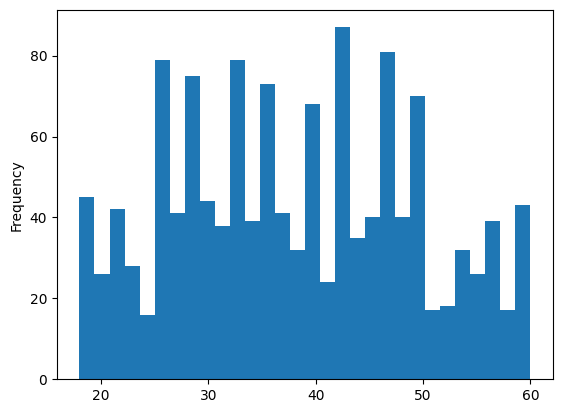

In [ ]:
df.age.plot(kind='hist',bins=30)

### Age Distribution — KDE Plot

A **KDE (Kernel Density Estimate)** plot provides a smooth estimate of the distribution of a numerical variable.

It helps us see where observations are concentrated and whether the distribution is approximately symmetric or skewed.


<Axes: ylabel='Density'>

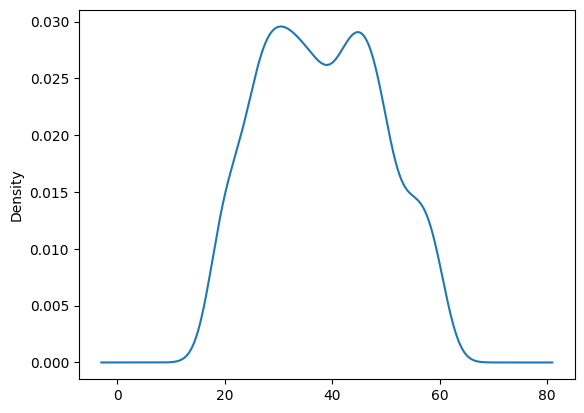

In [ ]:
df.age.plot(kind='kde')

### Age Skewness

`skew()` calculates the skewness of the Age distribution.

- Skewness near **0** → approximately symmetric
- Positive skewness → longer right tail
- Negative skewness → longer left tail

The numerical value supports the visual interpretation from the histogram and KDE plot.


In [ ]:
df.age.skew()

np.float64(0.11361133741072633)

### Age Box Plot

A **box plot** summarizes a numerical distribution using the median, quartiles, whiskers, and potential outliers.

The middle 50% of observations lie between Q1 and Q3. The difference is called the **Interquartile Range (IQR)**:

**IQR = Q3 − Q1**

Potential outliers are commonly investigated beyond:

**Q1 − 1.5 × IQR** and **Q3 + 1.5 × IQR**.

The notebook's conclusion is that no obvious Age outliers are present.


<Axes: >

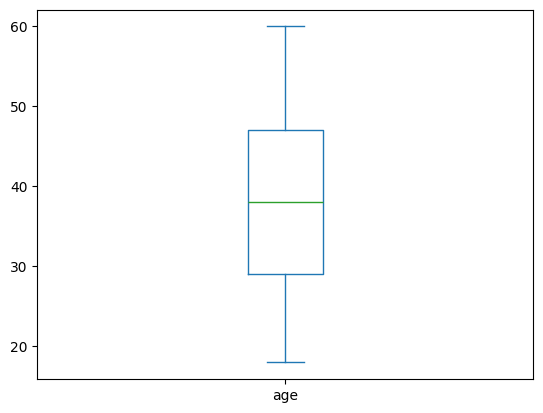

In [ ]:
df.age.plot(kind='box')

# 2. Univariate Analysis — Gender

`gender` is a categorical variable.

For categorical variables, we mainly examine:

- missing values
- frequency counts
- bar charts
- pie charts
- overall category balance

### Conclusions from the original analysis

- The number of males and females is similar.
- There are no missing values.


###Gender
**Conclusions**
- We have a similar number of males and females
- There are no missing values

### Checking Missing Gender Values

`isnull().sum()` checks whether any gender observations are missing.


In [ ]:
df.gender.isnull().sum()

np.int64(0)

### Gender Frequency Count

`value_counts()` counts the number of observations in each gender category.

This gives the numerical distribution before visualization.


In [ ]:
df.gender.value_counts()

,count
gender,
male,678
female,662


### Gender — Bar Chart

A **bar chart** compares the frequency of categorical values.

It makes the difference between the male and female counts easy to see.


<Axes: xlabel='gender'>

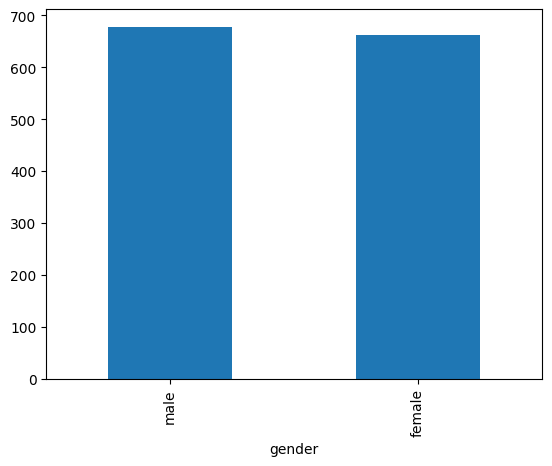

In [ ]:
df.gender.value_counts().plot(kind='bar')

### Gender — Pie Chart

A **pie chart** displays each category as a proportion of the total.

`autopct='%0.1f%%'` displays percentages with one decimal place.


<Axes: ylabel='count'>

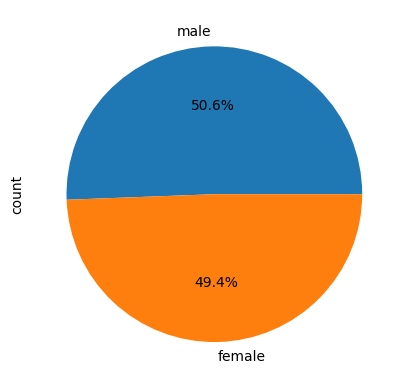

In [ ]:
df.gender.value_counts().plot(kind='pie',autopct='%0.1f%%')

# 3. Univariate Analysis — BMI

**BMI (Body Mass Index)** is a numerical variable.

The notebook examines:

1. Missing values
2. Frequency distribution
3. Descriptive statistics
4. Histogram
5. KDE plot
6. Skewness
7. Box plot
8. Potential outliers
9. BMI categorization

### Conclusions from the original analysis

- There are no missing BMI values.
- Potential outliers are present and should be checked for validity.
- The distribution is not strongly skewed according to the analysis.

> A statistical outlier is not automatically an incorrect medical observation. It should be investigated before deciding whether to remove it.


###bmi
**Conclusions**
- There are no missing values
- Outliers are present and should be checked to determine whether they are valid
- The data is not strongly skewed

### Checking Missing BMI Values

This checks the completeness of the BMI column.


In [ ]:
df.bmi.isnull().sum()

np.int64(0)

### BMI Frequency Count

`value_counts()` shows how frequently each exact BMI value occurs.

This can also help identify unusual repeated values that may deserve investigation.


In [ ]:
df.bmi.value_counts()

,count
bmi,
33.3,17
27.6,17
28.9,16
32.3,15
29.8,14
...,...
40.8,1
46.8,1
46.2,1


### BMI Descriptive Statistics

`describe()` summarizes the BMI distribution using count, mean, standard deviation, minimum, quartiles, and maximum.


In [ ]:
df.bmi.describe()

,bmi
count,1340.000000
mean,30.668955
std,6.106735
min,16.000000
25%,26.275000
50%,30.400000
75%,34.700000
max,53.100000


### Investigating BMI = 16

The rows with `BMI == 16` are inspected because this is a relatively low BMI value.

The purpose is to determine whether the observation is a valid value or a possible data-entry issue.


In [ ]:
df[df.bmi==16]

,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
48,34.0,male,16.0,83,No,0,No,northeast,1694.8


### BMI Histogram

The histogram shows how BMI values are distributed across intervals.

It helps identify concentration, spread, and possible extreme observations.


<Axes: ylabel='Frequency'>

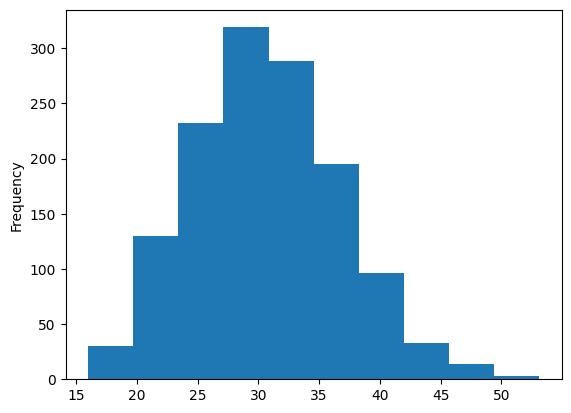

In [ ]:
df.bmi.plot(kind='hist')

### BMI KDE Plot

The KDE plot gives a smooth representation of the BMI distribution and helps assess its overall shape.


<Axes: ylabel='Density'>

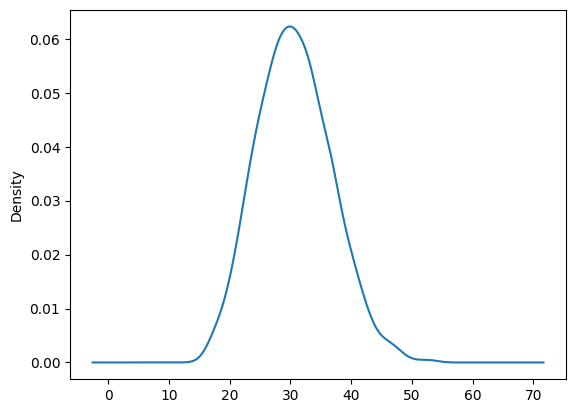

In [ ]:
df.bmi.plot(kind='kde')


### BMI Skewness

The skewness statistic provides a numerical measure of BMI distribution asymmetry.


In [ ]:
df.bmi.skew()

np.float64(0.28597245020808587)

### BMI Box Plot

The box plot is used to identify potential BMI outliers.

Potential outliers should be investigated in context rather than automatically deleted.


<Axes: >

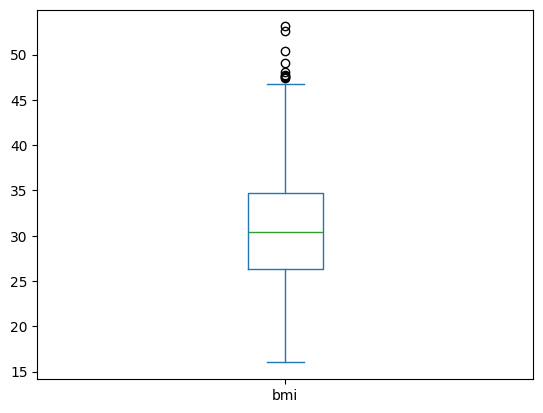

In [ ]:
df.bmi.plot(kind='box')

### Investigating High BMI Values

Rows with `BMI >= 47` are inspected as potential outliers.

The goal is to determine whether these are plausible BMI values or data errors. The notebook treats them as observations requiring investigation rather than automatically removing them.


In [ ]:
df[df.bmi>=47] ##outliers

,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
9,30.0,male,53.1,97,No,0,No,northwest,1163.46
141,46.0,male,50.4,89,Yes,1,No,southeast,2438.06
579,25.0,male,47.5,84,Yes,1,No,southeast,8083.92
675,49.0,female,48.1,81,Yes,2,No,northeast,9432.93
696,49.0,male,47.7,88,No,1,No,southeast,9748.91
802,42.0,male,49.1,109,Yes,0,No,southeast,11381.33
1299,50.0,male,52.6,110,No,1,Yes,southeast,44501.40
1306,43.0,female,47.6,112,Yes,2,Yes,southwest,46113.51
1339,30.0,female,47.4,101,No,0,Yes,southeast,63770.43


### Checking Blood Pressure Missing Values

The number of missing blood-pressure values is checked before creating blood-pressure categories.

This ensures that missing observations can be handled explicitly during feature engineering.


In [ ]:
df.bloodpressure.isnull().sum()

np.int64(0)

## 🧩 Feature Engineering — BMI Categories

The numerical BMI variable is converted into meaningful categorical groups.

The categories used in this notebook are:

- **Underweight** → BMI < 18.5
- **Normal** → 18.5 ≤ BMI < 25
- **Overweight** → 25 ≤ BMI < 29
- **Obesity** → BMI ≥ 29

A new column, `bmi_cat`, is created using the custom `bmi_categories()` function.

This is **feature engineering** because a new categorical feature is derived from an existing numerical feature.


In [ ]:
#we can categorize the bmi values
def bmi_categories(value):
  if value<18.5:
    return 'underweight'
  elif value>=18.5 and value<25:
    return 'normal'
  elif value>=25 and value<29:
    return 'overweight'
  else:
    return 'obesity'
df['bmi_cat']=df['bmi'].apply(bmi_categories)

### BMI Category Distribution

The new `bmi_cat` feature is visualized with a pie chart.

The notebook notes that the obesity category contains a large proportion of observations and compares the relative sizes of the BMI groups.

This visualization is used to understand the composition of the dataset after categorization.


<Axes: ylabel='count'>

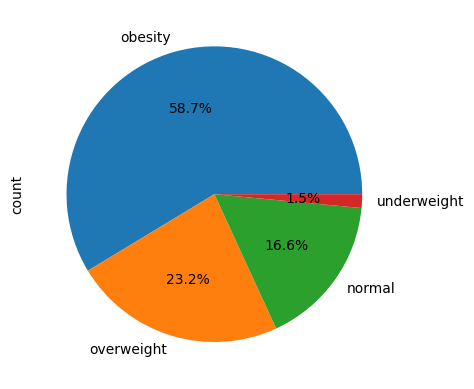

In [ ]:
df['bmi_cat'].value_counts().plot(kind='pie',autopct='%0.1f%%')
# Only 16.64% is below the normal category. Obesity is more common than overweight, which is
# also noteworthy.

### Average Insurance Claim by BMI Category

The mean insurance claim is calculated for each BMI category.

`groupby()` creates groups based on `bmi_cat`, while `mean()` calculates the average claim within each group.

This is a bivariate comparison between a categorical BMI feature and the numerical `claim` variable.


<Axes: title={'center': 'Avg insurance claim wrt differnt bmi cat'}, xlabel='bmi_cat'>

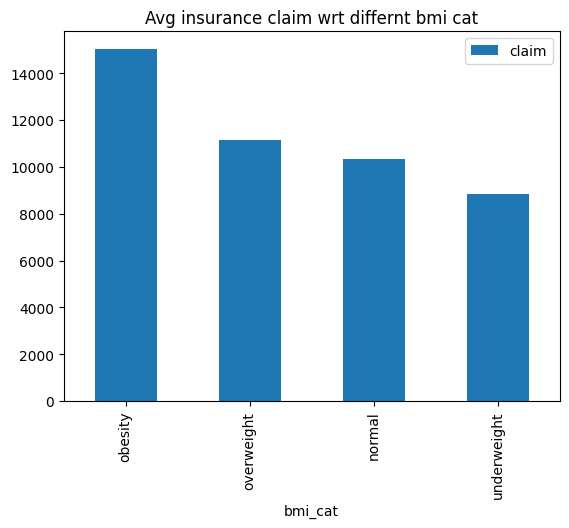

In [ ]:
df.groupby('bmi_cat')['claim'].mean().reset_index().sort_values(by='claim',ascending=False).plot(kind='bar',title='Avg insurance claim wrt differnt bmi cat',x='bmi_cat')
# Most people fall under obesity, and their claims are much higher than the other
# categories, which is an important observation. The next two categories are comparativelyd of similar.

### Age Statistics by BMI Category

The mean and median Age are calculated for each BMI category.

Comparing both **mean** and **median** is useful because the median is less affected by extreme observations than the mean.

The notebook observes that average ages are relatively similar across the categories, while the underweight group has the lowest median age.


In [ ]:
df.groupby('bmi_cat')['age'].agg(func=['mean','median']).reset_index().sort_values(by='mean',ascending=False)
# The average age for each BMI category is almost the same. The median value of
# 'underweight' is the lowest among the categories.

,bmi_cat,mean,median
2,overweight,39.157556,39.0
3,underweight,38.500000,35.0
0,normal,38.017937,37.0
1,obesity,37.655570,37.0


### Age Distribution Across BMI Categories — Violin Plot

A **violin plot** combines information about a box plot and a KDE-style distribution.

It helps compare the shape, spread, and concentration of Age across BMI categories.

The original analysis notes differences in distribution shape, including possible bimodal behaviour in some categories and a right-skewed underweight distribution.


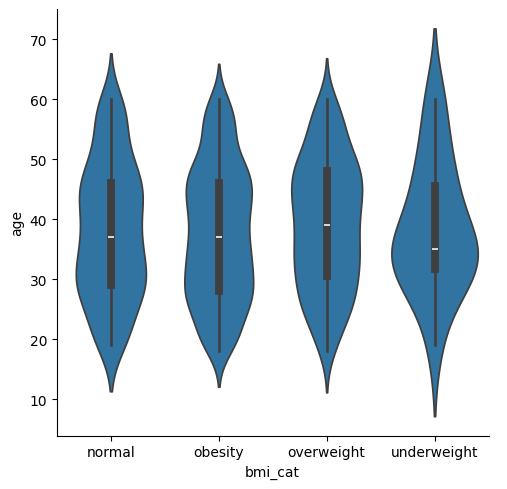

In [ ]:
# Examine the distribution of Age for each BMI category
sns.catplot(x="bmi_cat", y="age", data=df, kind="violin")
plt.show()

# 'normal' and 'obesity' tend toward a bimodal distribution. The peak width of
# 'overweight' is much more spread out. Also, the 'underweight' Age distribution is
# right skewed. Also can see the medians which are discovered to the above. The
# IQR of "overweight" is higher compared to others.

# 4. Univariate / Feature Analysis — Blood Pressure

Blood pressure is converted into categorical groups so that claim behaviour can be compared across blood-pressure ranges.

The original notebook does not provide a written conclusion under this heading, so the observations are explained from the actual operations and comments in the following cells.


###Bloodpressure
**Conclusions**

### 🩺 Creating Blood Pressure Categories

The custom `blood_pressure_cat()` function converts numerical blood-pressure values into categories:

- **normal** → below 120
- **elevated** → 120–129
- **hbp-stage1** → 130–139
- **hbp-stage2** → 140–179
- **hypertensive_crisis** → 180 or above
- missing values remain missing

The new `blood_pressure_cat` column is created using `apply()`.

This is another example of feature engineering: a continuous numerical variable is transformed into a categorical feature.


In [ ]:
# Categorize blood pressure
def blood_pressure_cat(value):
    if pd.isna(value):
        return np.nan

    if value < 120:
        return "normal"
    elif value >= 120 and value < 130:
        return "elevated"
    elif value >= 130 and value < 140:
        return "hbp-stage1" # high blood pressure stage 1
    elif value >= 140 and value < 180:
        return "hbp-stage2" # high blood pressure stage 2
    elif value >= 180:
        return "hypertensive_crisis"
    else:
        return value

# Convert blood pressure to categorical
df["blood_pressure_cat"] = df["bloodpressure"].apply(
    lambda x: blood_pressure_cat(x)
).copy()

### Blood Pressure Category Frequency

`value_counts()` shows how many observations fall into each blood-pressure category.

This helps us understand the composition of the dataset after categorization.


In [ ]:
df['blood_pressure_cat'].value_counts()

,count
blood_pressure_cat,
normal,1281
elevated,30
hbp-stage1,24
hbp-stage2,5


### Claim Statistics by Blood Pressure Category

The notebook calculates:

- **mean**
- **median**
- **maximum**
- **minimum**

claim amounts for each blood-pressure category.

The results are sorted by mean claim.

The conditional styling highlights different claim ranges to make the table easier to inspect.

The original observation is that normal blood-pressure patients have much lower typical claims, while the maximum claim in the dataset can still occur in the normal category. This illustrates why both average and extreme values should be considered.


In [ ]:
def color_negative_red(val):
  color='red' if val<30_000 else 'blue' if val > 60_000 else 'black'
  return 'color:%s'%color
df.groupby('blood_pressure_cat')['claim'].agg(func=['mean','median','max','min']).sort_values(by='mean',ascending=False).style.map(color_negative_red)
# Normal-blood-pressure observations have much lower typical claims than the other categories.
# blood pressure categorized people. But the highest claim of this dataset came
# from the "normal" blood pressure category.

,mean,median,max,min
blood_pressure_cat,,,,
elevated,38810.656000,38496.875000,58571.070000,26018.950000
hbp-stage2,38323.496000,36950.260000,43753.340000,35491.640000
hbp-stage1,37002.625833,38495.975000,48517.560000,26140.360000
normal,12111.380937,8871.150000,63770.430000,1121.870000


### Blood Pressure Category × BMI Category

A pivot table compares Age and Claim across both `blood_pressure_cat` and `bmi_cat`.

This is a **multivariate analysis** because multiple variables are considered simultaneously.

The notebook highlights cells using conditional formatting to make notable values easier to identify.

The original observation is that underweight observations tend to have normal blood pressure, while the high-blood-pressure stage-2 observations in this dataset fall within the obesity category.


In [ ]:
# Examine relationships between "blood_pressure_cat" and "bmi_cat" with "age"
# "claim"
def change_age_color(val):
    color = 'red' if val < 30 else 'black'
    return 'color: %s' % color

def change_claim_color(val):
    color = "red" if val < 30_000 else "black"
    return "color: %s" % color
df.pivot_table(values=['age','claim'],index='blood_pressure_cat',columns='bmi_cat').style.highlight_null("#e14258",) \
    .applymap(change_age_color, subset="age") \
    .applymap(change_claim_color, subset="claim")

# Underweight observations tend to have normal blood pressure. Also, all the high-
# blood-pressure level 2 people belong to obesity. And, the interesting values
# are highlighted!!

/tmp/ipykernel_1430/39075741.py:11: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(change_age_color, subset="age") \
/tmp/ipykernel_1430/39075741.py:12: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(change_claim_color, subset="claim")


### Claim Distribution by Blood Pressure Category and Gender

A violin plot compares claim distributions across blood-pressure categories while separating the distributions by gender.

This visualization combines:
- blood-pressure category
- claim amount
- gender

The original analysis observes differences in the spread of claims between males and females across some blood-pressure categories.


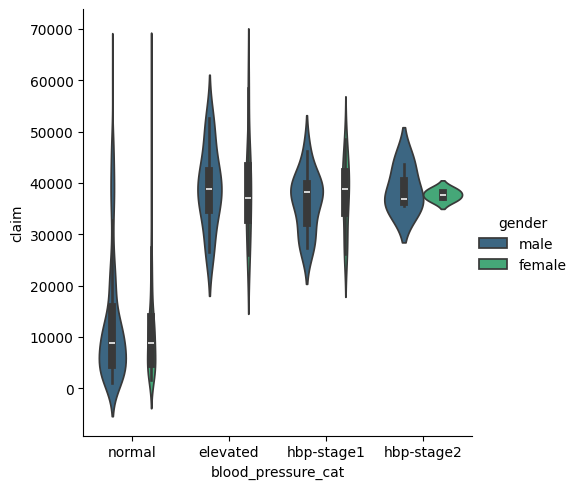

In [ ]:
sns.catplot(x="blood_pressure_cat", y="claim", data=df, hue="gender",
            kind="violin", palette = "viridis")
plt.show()

# The insurance claim distributions differ across categories, as reflected here for both genders. The 'elevated'
# other # and 'hbp-stage1' females have more widely spread claims than males. For 'hbp-stage2'
# and "hbp-stage1" females more spread claims that the males. For "hbp-stage2"
# male claims span a wider range than female claims.

# 5. Univariate Analysis — Diabetic Status

`diabetic` is a categorical variable indicating diabetic and non-diabetic observations.

### Conclusions from the original analysis

- There are no missing values.
- The number of diabetic and non-diabetic observations is similar.


###Diabatic
**Conclusions**
- There are no null values
- There are similar numbers of diabetic and non-diabetic observations

### Checking Missing Diabetic Values

This checks whether any diabetic-status values are missing.


In [ ]:
df.diabetic.isnull().sum()

np.int64(0)

### Diabetic Status Frequency

`value_counts()` shows the number of diabetic and non-diabetic observations.


In [ ]:
df.diabetic.value_counts()

,count
diabetic,
No,698
Yes,642


### Diabetic Status — Pie Chart

The pie chart shows the proportion of diabetic and non-diabetic observations.


<Axes: ylabel='count'>

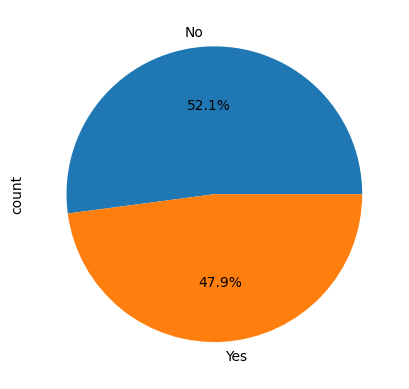

In [ ]:
df.diabetic.value_counts().plot(kind='pie',autopct='%0.1f%%')

### Diabetic Status — Bar Chart

The bar chart provides a direct comparison of the frequencies of the two categories.


<Axes: xlabel='diabetic'>

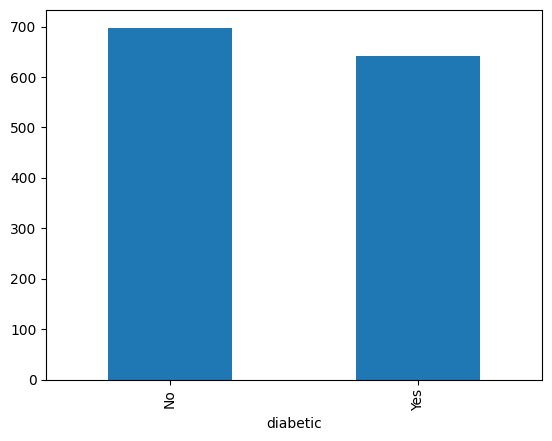

In [ ]:
df.diabetic.value_counts().plot(kind='bar')

### End of Diabetic Analysis

No additional operation is performed in this cell. The previous frequency tables and visualizations provide the main univariate analysis for diabetic status.


# 6. Univariate Analysis — Children

`children` is a numerical count variable representing the number of children associated with the observation.

The analysis checks missing values, frequency counts, and the distribution using a histogram and KDE plot.

The original Markdown did not contain a written conclusion for this section, so no unsupported conclusion is added here.


###children
**Conclusions**


### Checking Missing Children Values

This checks whether the `children` column contains missing observations.


In [ ]:
df.children.isnull().sum()

np.int64(0)

### Children Frequency Count

`value_counts()` shows how frequently each number of children occurs.

Because this is a count variable with relatively few possible values, frequency counts are particularly useful.


In [ ]:
df.children.value_counts(
)

,count
children,
0,576
1,324
2,240
3,157
4,25
5,18


### Children — Histogram

The histogram shows the distribution of the number of children across the dataset.


<Axes: ylabel='Frequency'>

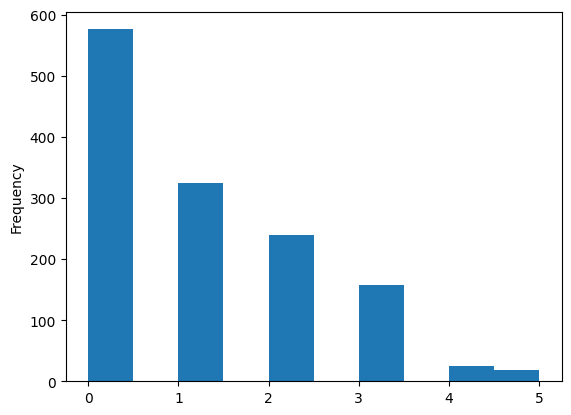

In [ ]:
df.children.plot(kind='hist')

### Children — KDE Plot

The KDE plot provides a smoothed representation of the distribution.

For discrete count data, the frequency table is often more directly interpretable than KDE, but the plot can still be used as a visual representation of the distribution.


<Axes: ylabel='Density'>

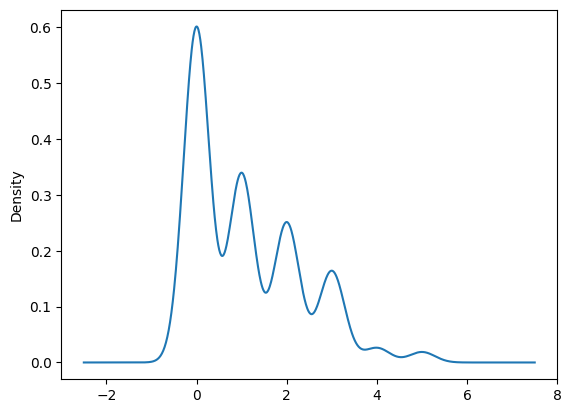

In [ ]:
df.children.plot(kind='kde')

# 7. Univariate Analysis — Smoker Status

`smoker` is a categorical variable indicating whether an individual is a smoker.

### Corrected conclusion

- A **smaller proportion of people are smokers than non-smokers**.

The original conclusion contained spelling errors and was rewritten for clarity without changing its intended meaning.


###Smoker
**Conclusions***
- A smaller proportion of people are smokers than non-smokers

### Checking Missing Smoker Values

This checks the completeness of the smoker-status column.


In [ ]:
df.smoker.isnull().sum()

np.int64(0)

### Smoker Status Frequency

`value_counts()` shows the number of smokers and non-smokers.


In [ ]:
df.smoker.value_counts()

,count
smoker,
No,1066
Yes,274


### Smoker Status — Bar Chart

The bar chart compares smoker and non-smoker frequencies.


<Axes: xlabel='smoker'>

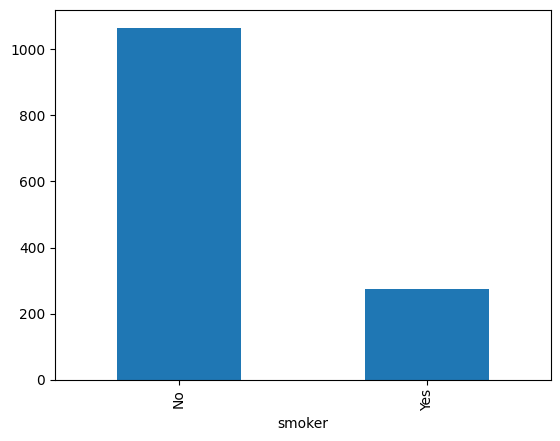

In [ ]:
df.smoker.value_counts().plot(kind='bar')

### Smoker Status — Pie Chart

The pie chart shows the proportion of smokers and non-smokers in the dataset.


<Axes: ylabel='count'>

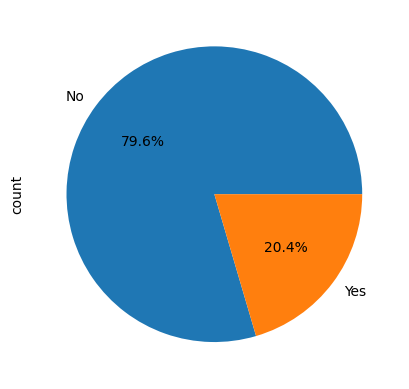

In [ ]:
df.smoker.value_counts().plot(kind='pie',autopct='%0.1f%%')

# 8. Univariate Analysis — Region

`region` is a categorical variable representing the geographic region associated with the observation.

### Corrected conclusion

- **Southeast has the highest number of insured people** in the dataset.

The spelling and grammar of the original conclusion have been corrected.


###region
**Conclusions**
- Southeast has the highest number of insured people

### Checking Missing Region Values

This checks whether any region values are missing.


In [ ]:
df.region.isnull().sum()

np.int64(3)

### Inspecting Missing Region Records

Rows with missing region values are displayed for further inspection.


In [ ]:
df[df.region.isnull()]

,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim,bmi_cat,blood_pressure_cat
13,32.0,male,27.6,100,No,0,No,NaN,1252.41,overweight,normal
14,40.0,male,28.7,81,Yes,0,No,NaN,1253.94,overweight,normal
15,32.0,male,30.4,86,Yes,0,No,NaN,1256.30,obesity,normal


### Region Frequency

`value_counts()` counts observations in each geographic region.


In [ ]:
df.region.value_counts()

,count
region,
southeast,443
northwest,349
southwest,314
northeast,231


### Region — Bar Chart

The bar chart compares the number of insured people across regions.


<Axes: xlabel='region'>

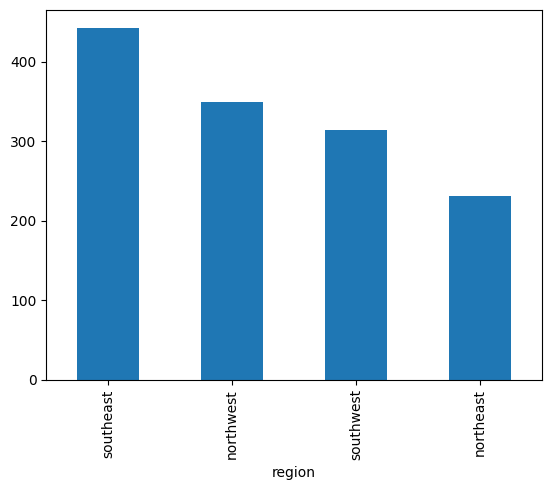

In [ ]:
df.region.value_counts().plot(kind='bar')

### Region — Pie Chart

The pie chart shows the percentage contribution of each region to the dataset.


<Axes: ylabel='count'>

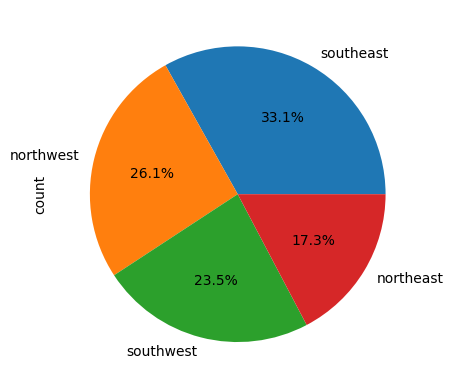

In [ ]:
df.region.value_counts().plot(kind='pie',autopct='%0.1f%%')

# 9. Univariate Analysis — Claim

`claim` is the numerical insurance-claim amount.

### Corrected conclusions

- There are **no missing Claim values**.
- The Claim distribution is **skewed**.

The following cells quantify and visualize this skewness.


###Claim
**Conclusions**
- There are no missing values
- The data is skewed

### Checking Missing Claim Values

This checks the completeness of the Claim column.


In [ ]:
df.claim.isnull().sum()

np.int64(0)

### Claim Descriptive Statistics

`describe()` summarizes the Claim distribution using count, mean, standard deviation, minimum, quartiles, and maximum.

These statistics help explain the scale and spread of insurance claims.


In [ ]:
df.claim.describe()

,claim
count,1340.000000
mean,13252.745642
std,12109.609288
min,1121.870000
25%,4719.685000
50%,9369.615000
75%,16604.305000
max,63770.430000


### Claim Histogram

The histogram visualizes the distribution of insurance claims.

A long tail toward higher claim amounts indicates positive/right skewness.


<Axes: ylabel='Frequency'>

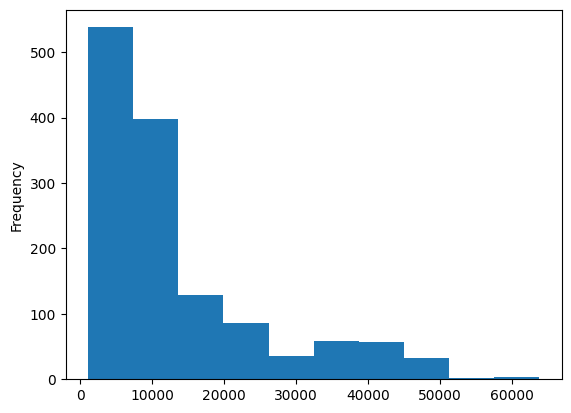

In [ ]:
df.claim.plot(kind='hist')

### Claim KDE Plot

The KDE plot provides a smoothed representation of the Claim distribution and helps visualize its shape.


<Axes: ylabel='Density'>

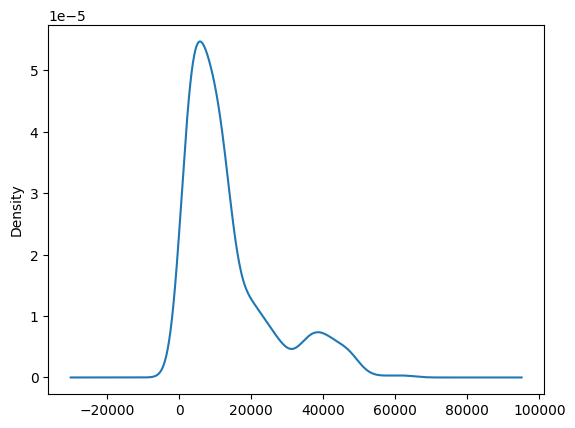

In [ ]:
df.claim.plot(kind='kde')

### Claim Skewness

The `skew()` method provides a numerical measure of the asymmetry of the Claim distribution.

The result supports the notebook's conclusion that Claim is skewed.


In [ ]:
df.claim.skew()

np.float64(1.5167468509489237)

# 10. Multivariate Analysis — Pair Plot

A **pair plot** visualizes pairwise relationships among selected numerical variables.

The notebook examines:

- Age
- BMI
- Blood Pressure
- Claim

The `hue="gender"` argument separates observations by gender.

This allows us to examine both distributions and relationships between numerical variables while also considering gender as a grouping variable.

The original comments observe differences in the spread of Age and the tails of the distributions between genders.


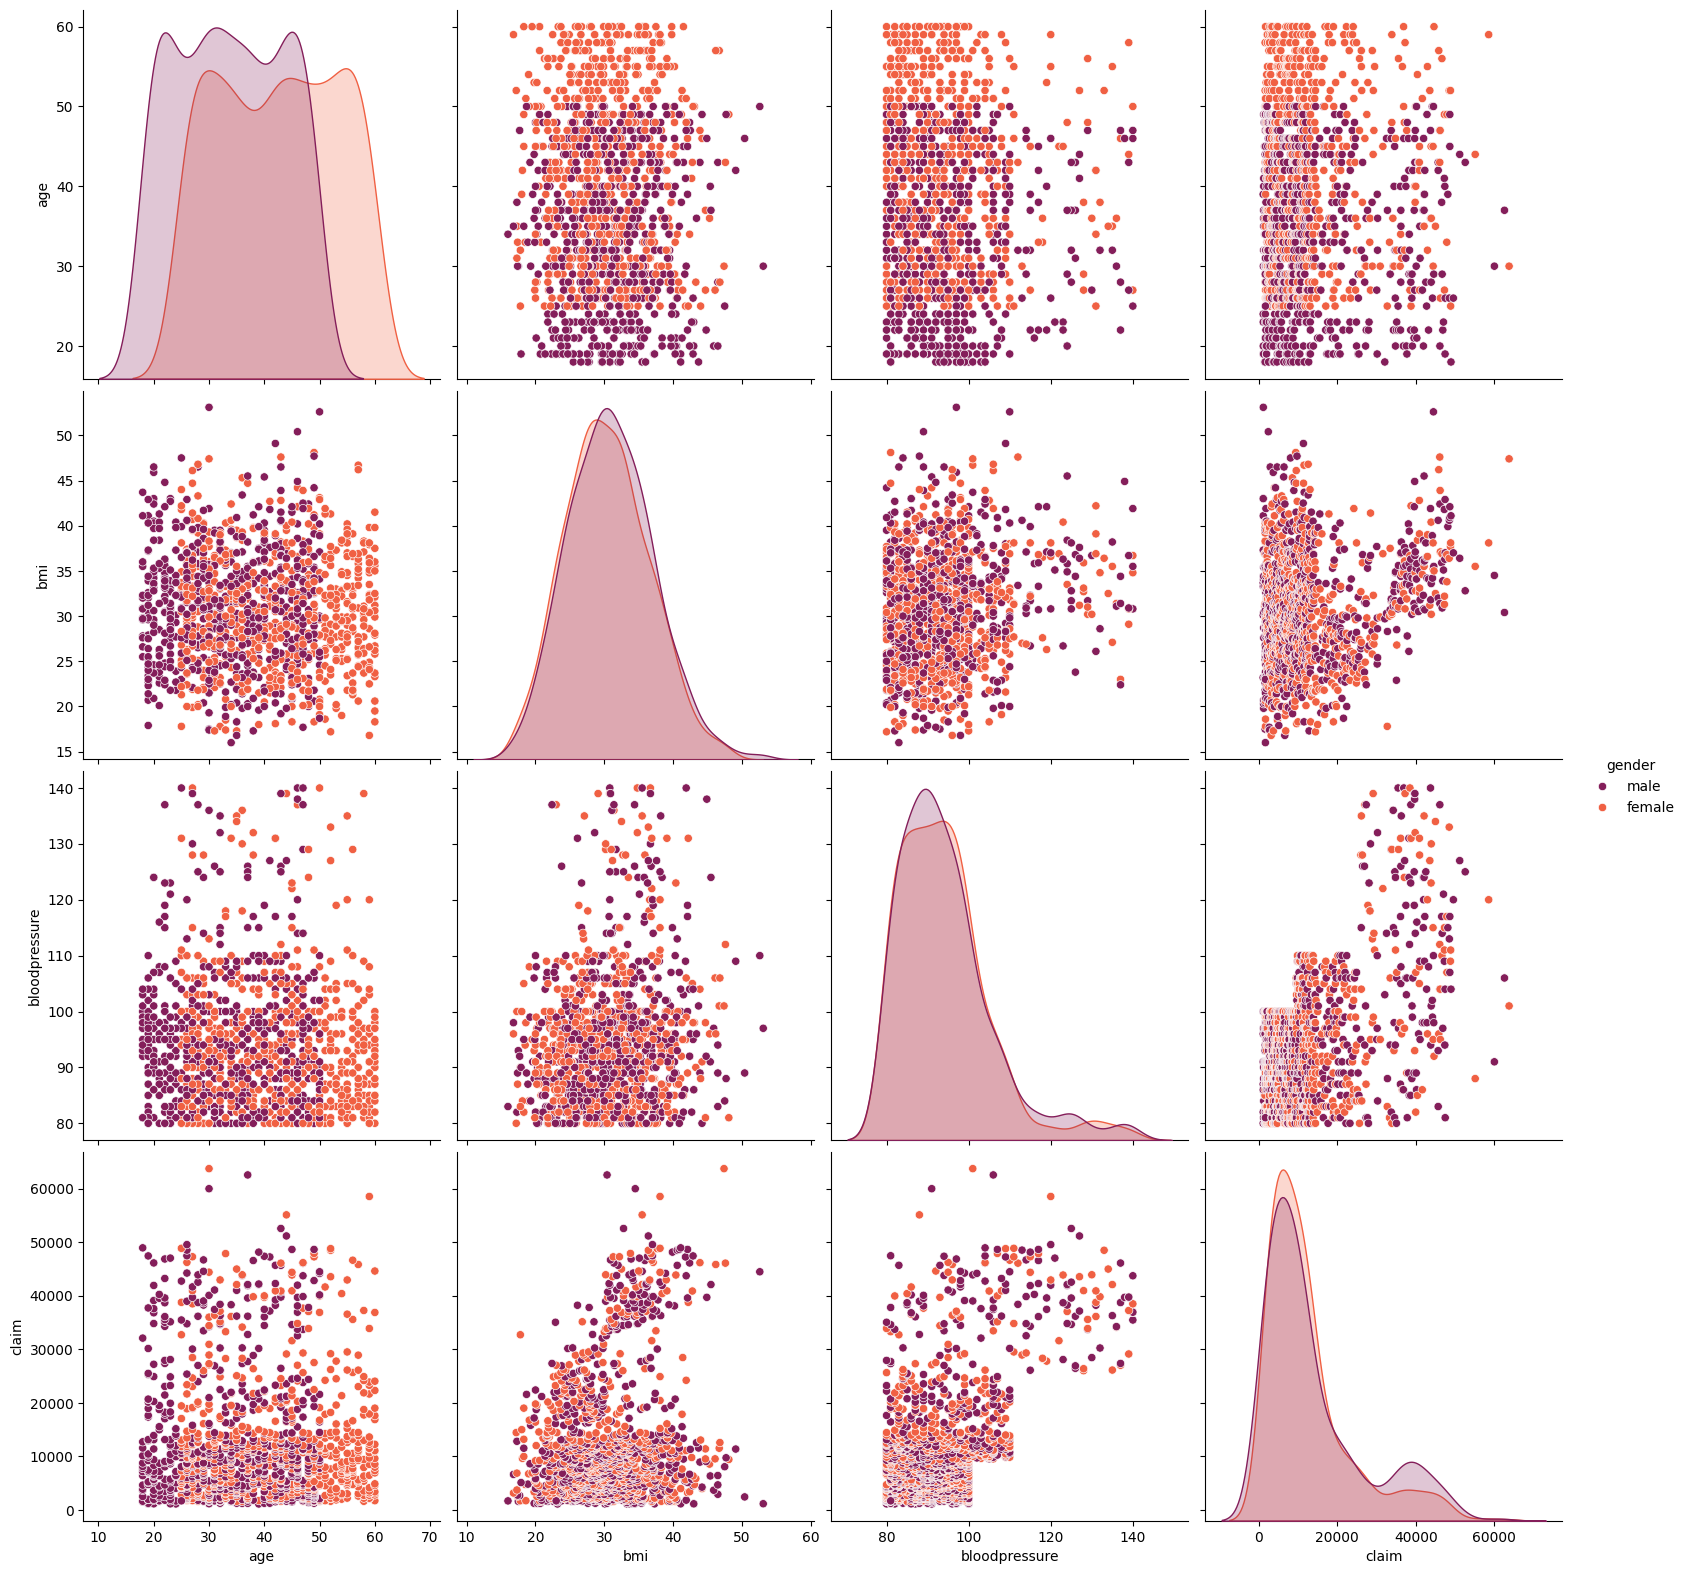

In [ ]:
sns.pairplot(
    data=df,
    hue="gender",
    vars=["age", "bmi", "bloodpressure", "claim"],
    height=4,
    aspect=1,
    palette = "rocket"
)
plt.show()

# The distribution of the col. "age" is much wider. Also, there are very less
# values to the tails. The female "age" is right shifted than the males.

# The peak is higher than the normal distributioin for the "bmi" distribution.
# Also, there is a tendency to the right skewed. That's why "obecity" % is
# hogher than the others. Most of the parts of male and female are overlapping.

# For the "bloodpressure" and "claim", the distributions are right skewed. Also,
# has a bimodal tendency at high values. Most parts of male and female are
# overlapping.

# From "age" vs. "bmi" we can't find such noticeable relationship. But for low
# age values (< 25), there is no "female" and for high age (>51) values, there
# is no "male".

# Same type of pattern is there for "age" vs. "bloodpressure". After around
# bloodpressure 110, the density is reduced. Same thing with "age" vs "claim".

# For "bmi" vs "bloodpressure", in less than 25 bmi, most are female. So females
# are mostly health conscious.

# From "bmi" vs "claim" plot, we can devide the data into 2 or 3 clusters. Very
# less people claim between 20_000 to 40_000. Those who claimed in this range,
# the age is near about 30. For age 30-40 and claim around 35_000 to 45_000,
# that cluster might have a linear trend to upwards.

# For "bloodpressure" vs. "claim", we can see that there are probably 3 stages.
# And the trend is upwards. Also, by increasing the stages, the density is
# reduced. For "claim" 15_000 to 20_000 and "bloodpressure" around 85-100,
# the female density is higher than male.

# 11. Claim by Gender and Region

This box plot compares Claim distributions between genders separately for each region.

### Terms

**IQR (Interquartile Range):** The range between Q1 and Q3. It represents the middle 50% of observations.

The original observation is that the male groups generally have a wider IQR than the female groups, while the medians are relatively similar. Because Claim is skewed, several high-value observations appear as potential outliers.


/tmp/ipykernel_1430/1083925183.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data=df.dropna(), x="gender", y='claim', col="region", kind='box',


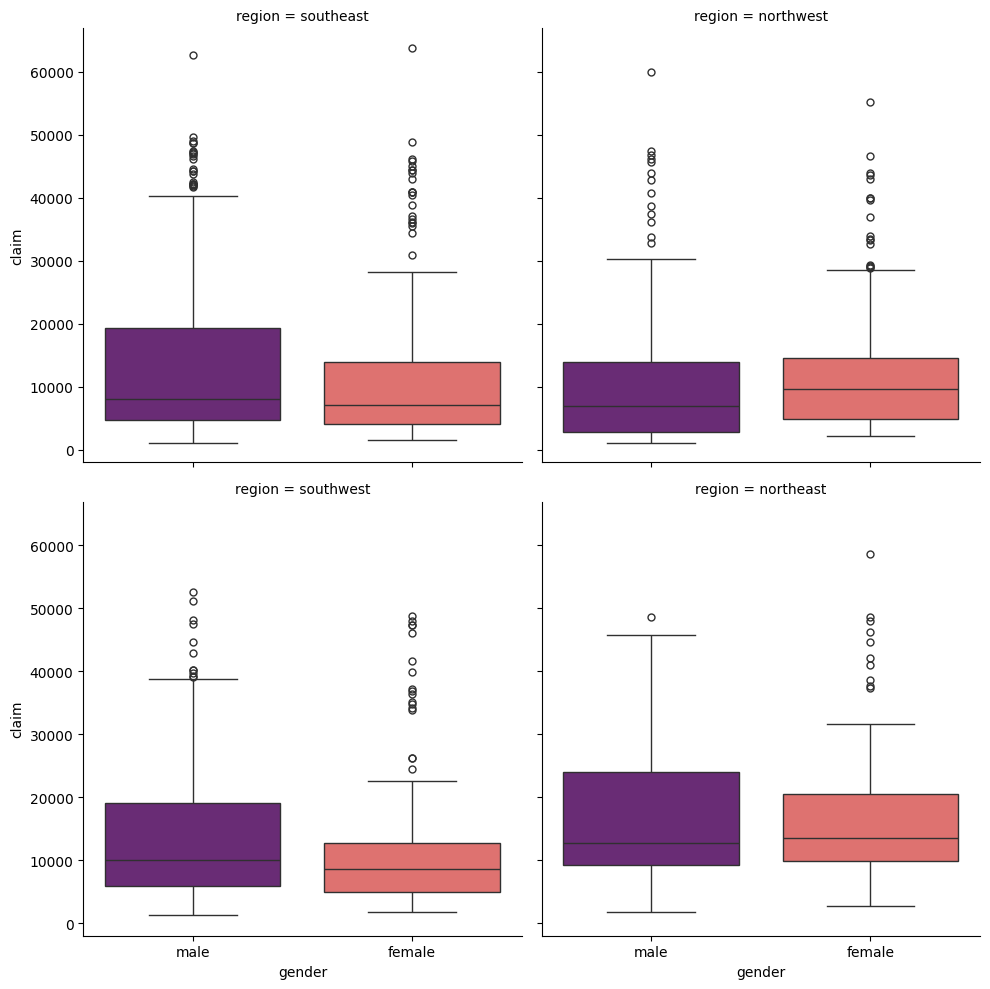

In [ ]:
sns.catplot(data=df.dropna(), x="gender", y='claim', col="region", kind='box',
            col_wrap=2, palette="magma");

# The IQR of males is generally much bigger than females. But the median is
# similar. We already know that the distribution of the "claim", so there will
# be some outliers which can be seen for every region.

# 12. Age by Gender, Smoking Status, and Region

This box plot compares Age across:

- gender
- smoker status
- region

The original observation is that smokers tend to show higher Age values than non-smokers in the plotted groups, and differences between male and female Age distributions are visible.

The box plot also helps inspect the spread and potential outliers within each subgroup.


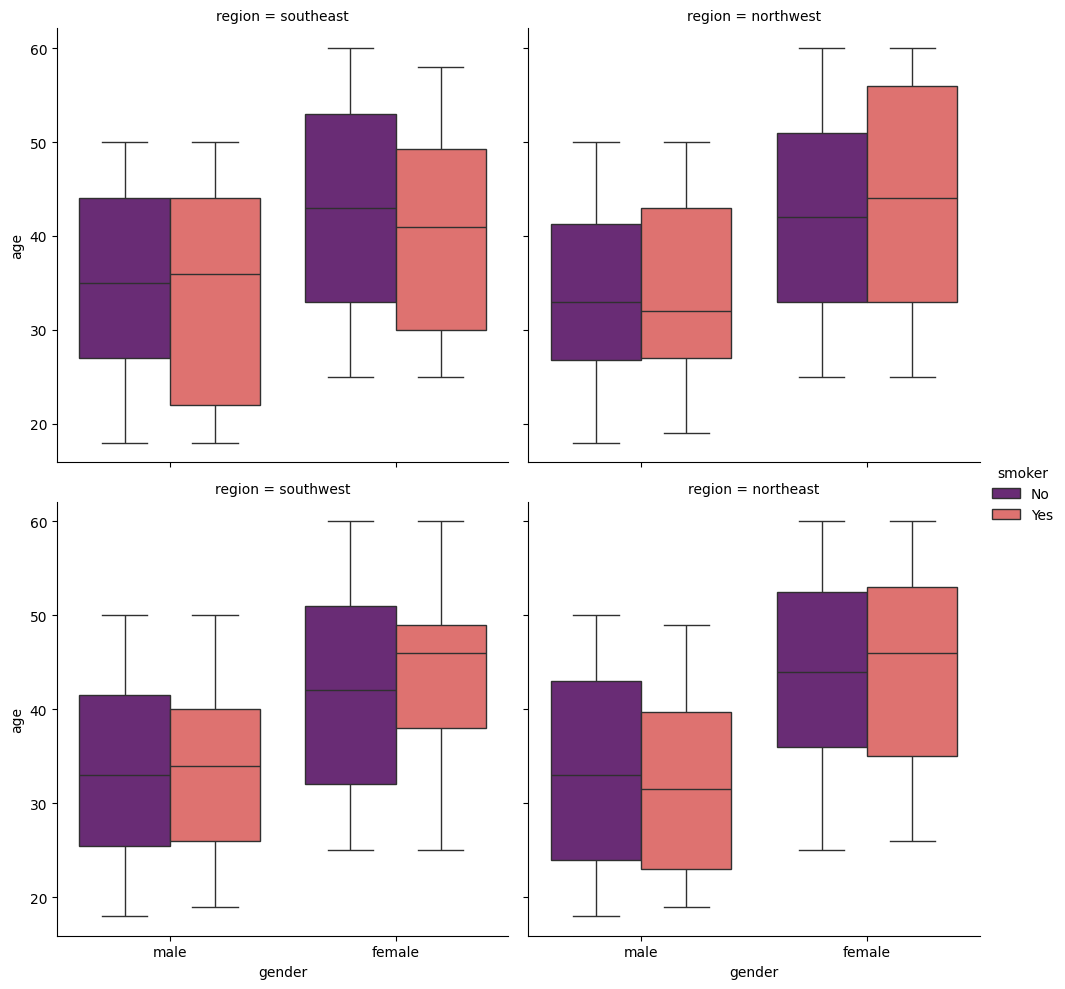

In [ ]:
sns.catplot(data=df.dropna(), x="gender", y='age', hue="smoker", col="region",
            kind='box', col_wrap=2, palette="magma");

# Mostly smoker is bigger than the non-smoker for both "male" and "female". ALso
# age difference between "male" and "female" is noticeable. But there is no
# outlier for any graph. For each region, the medians for smoker or non-smoker
# are very close whether it is "male" or "female" plot.

# 13. Age by Smoking and Diabetic Status

This visualization compares Age across smoker categories while using diabetic status and region as additional grouping variables.

This is a multivariate analysis because several variables are considered together.

The original comments note differences in the age ranges of smoker/non-diabetic groups across regions and relatively similar medians in many groups.


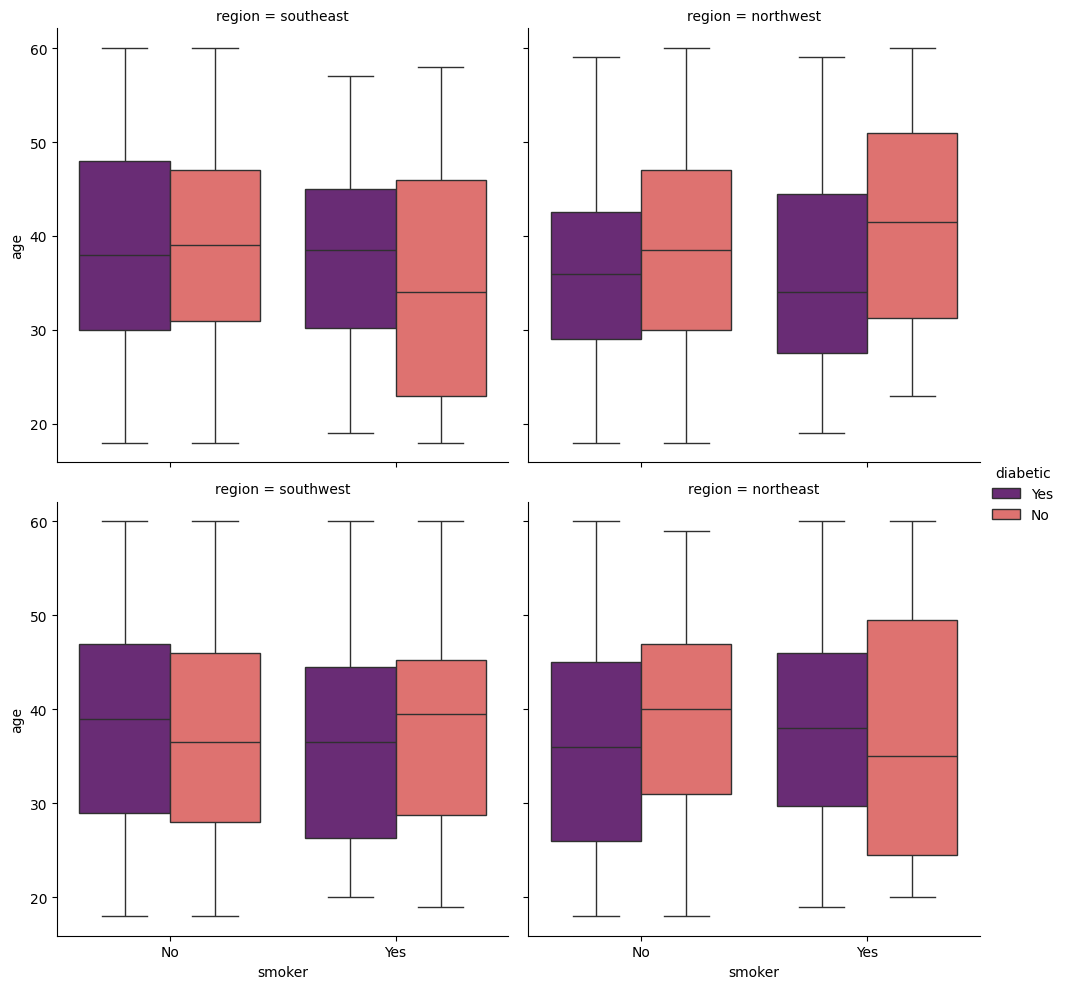

In [ ]:
sns.catplot(data=df.dropna(), x="smoker", y='age', hue="diabetic", col="region",
            kind='box', col_wrap=2, palette="magma");

# Smoker non-diabetic wide range of age people of southeast and norteast plots
# are different than others. The medians are kind of similar except northwest
# smoker people. Also, no outlier is spotted in any plot.

# 14. Claim by Smoking and Diabetic Status

This box plot compares Claim across smoker groups, separated by diabetic status and region.

The main observation from the original analysis is:

- Smokers tend to have much higher insurance claims than non-smokers.
- In the Southeast region, the smoker/non-diabetic group has a comparatively wider IQR.

The plot also helps reveal the spread and potential high-claim outliers.


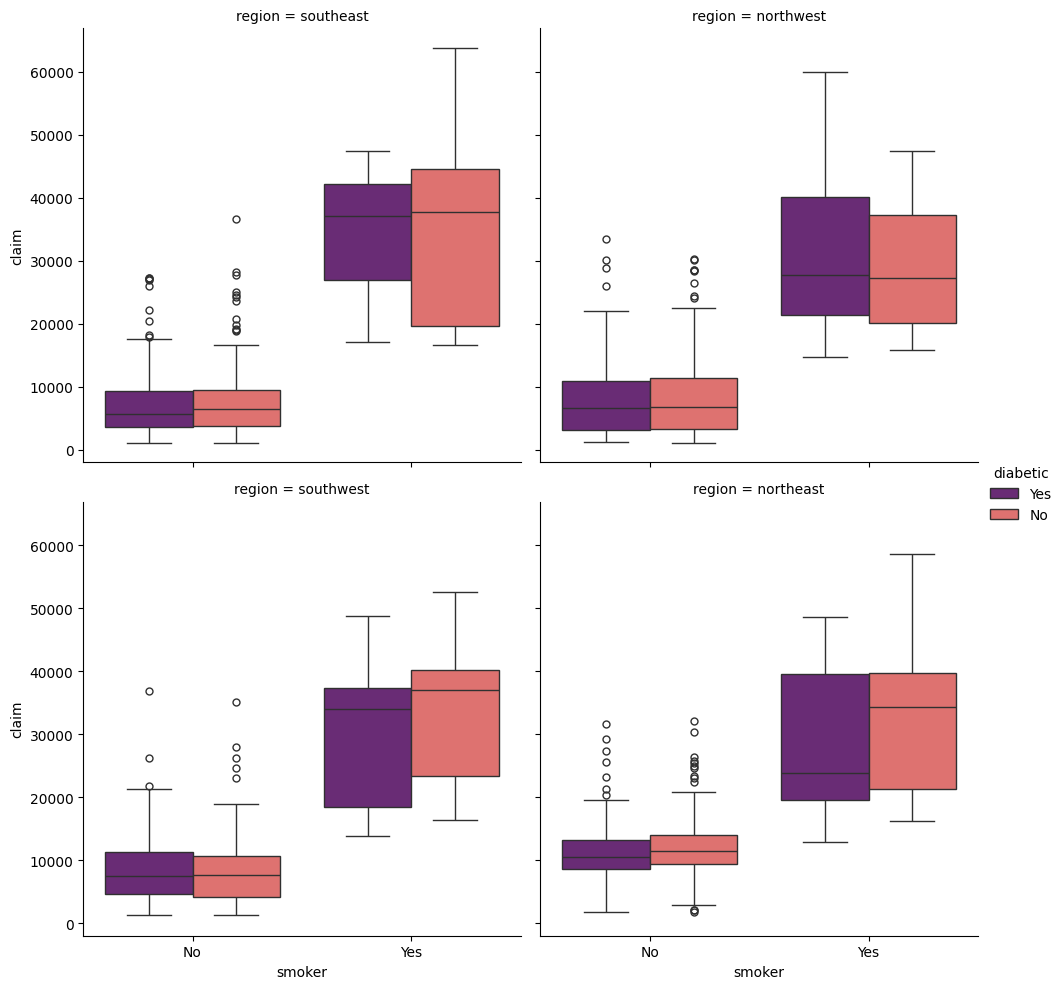

In [ ]:
sns.catplot(data=df.dropna(), x="smoker", y='claim', hue="diabetic",
            col="region", kind='box', col_wrap=2, palette="magma");

# Those who are smoker, claimed much higher than the non-smoker people. For
# southeast region, the smoker non-diabetic IQR is bigger than others. Most of
# the medians are similar for diabetic or non-diabetic. But this pattern is
# changed with smoker northeast people. Also, the outliers are only there for
# non-smoker people which tell that the non-smoker people also claimed for the
# higher insurance but the number of people is less than the smoker people.

# 15. Comparing All Major Categorical Variables

The categorical variables:

- `gender`
- `smoker`
- `diabetic`
- `region`

are collected into a list and visualized together using multiple bar charts.

This provides a compact comparison of the frequency distribution of the major categorical variables in the dataset.


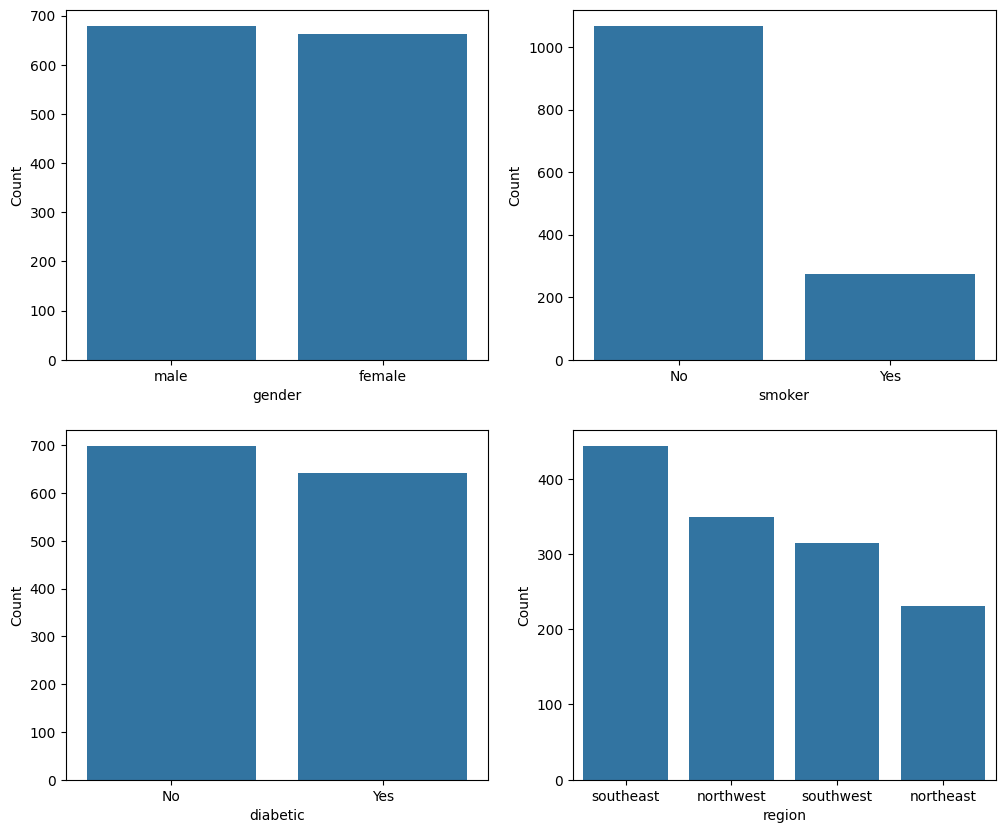

In [ ]:
cat_variables = ["gender", "smoker", "diabetic", "region"]

fig, axs = plt.subplots(2, 2, figsize=(12, 10))

for index, ax in enumerate(fig.axes):
    sns.barplot(y=df[cat_variables[index]].value_counts(),
                x=df[cat_variables[index]].value_counts().index, ax=ax)
    ax.set_ylabel("Count")
    ax.set_xlabel(cat_variables[index])

plt.show()

# In our dataset, based on "gender", the data is balanced but non-balanced
# based on smoker. Very high non-smoker are there. Also, balanced type in
# "diabetic" dataset. And most of the people came from the "southeast" region
# and very less from the "northeast".

# 📌 Final EDA Summary

This notebook demonstrates a structured exploratory analysis of an insurance dataset.

## Analysis Covered

### Univariate Analysis
- Missing-value checks
- Frequency distributions
- Descriptive statistics
- Histograms
- KDE plots
- Skewness
- Box plots
- Categorical distributions

### Feature Engineering
- BMI categories
- Blood-pressure categories

### Bivariate / Multivariate Analysis
- Claim by BMI category
- Age by BMI category
- Claim by blood-pressure category
- Blood pressure × BMI × Age/Claim
- Claim by gender and blood-pressure category
- Pairwise numerical relationships
- Claim by gender and region
- Age by gender, smoker status, and region
- Age by smoker and diabetic status
- Claim by smoker and diabetic status
- Frequency comparison of major categorical variables

## Key EDA Concepts

**Univariate Analysis** → understand one variable.

**Bivariate Analysis** → understand the relationship between two variables.

**Multivariate Analysis** → analyze several variables together.

**Skewness** → quantify the asymmetry of a numerical distribution.

**Outlier** → an unusually distant observation that should be investigated before removal.

**Feature Engineering** → create useful new variables from existing variables.

**IQR** → the range between the first and third quartiles, representing the middle 50% of observations.

The main purpose of this notebook is to move from **raw data → statistical understanding → visual exploration → meaningful observations → useful engineered features**.
